In [1]:
# ============================================================
# 02_funnel_analysis.ipynb
# Funnel Analysis - Core drop-off visualisation
# ============================================================

# Imports and connection
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from db_connection import get_engine

engine = get_engine()
print("Connected.")

Connected.


In [7]:
# Load funnel data from PostgreSQL
query = """
SELECT
    COUNT(DISTINCT CASE WHEN event_type = 'view'     THEN user_id END) AS users_viewed,
    COUNT(DISTINCT CASE WHEN event_type = 'cart'     THEN user_id END) AS users_carted,
    COUNT(DISTINCT CASE WHEN event_type = 'purchase' THEN user_id END) AS users_purchased
FROM events_clean;
"""
funnel_df = pd.read_sql(query, engine)
print(funnel_df)

   users_viewed  users_carted  users_purchased
0        406817         36948            21304


In [3]:
# Funnel metrics
stages      = ['View', 'Cart', 'Purchase']
users       = [
    int(funnel_df['users_viewed'][0]),
    int(funnel_df['users_carted'][0]),
    int(funnel_df['users_purchased'][0])
]

# Conversion rates
view_to_cart       = round(users[1] / users[0] * 100, 2)
cart_to_purchase   = round(users[2] / users[1] * 100, 2)
overall            = round(users[2] / users[0] * 100, 2)

# Drop-off rates
drop_view_cart     = round(100 - view_to_cart, 2)
drop_cart_purchase = round(100 - cart_to_purchase, 2)

print(f"View → Cart conversion:      {view_to_cart}%")
print(f"Cart → Purchase conversion:  {cart_to_purchase}%")
print(f"Overall conversion:          {overall}%")
print(f"View → Cart drop-off:        {drop_view_cart}%")
print(f"Cart → Purchase drop-off:    {drop_cart_purchase}%")

View → Cart conversion:      9.08%
Cart → Purchase conversion:  57.66%
Overall conversion:          5.24%
View → Cart drop-off:        90.92%
Cart → Purchase drop-off:    42.34%


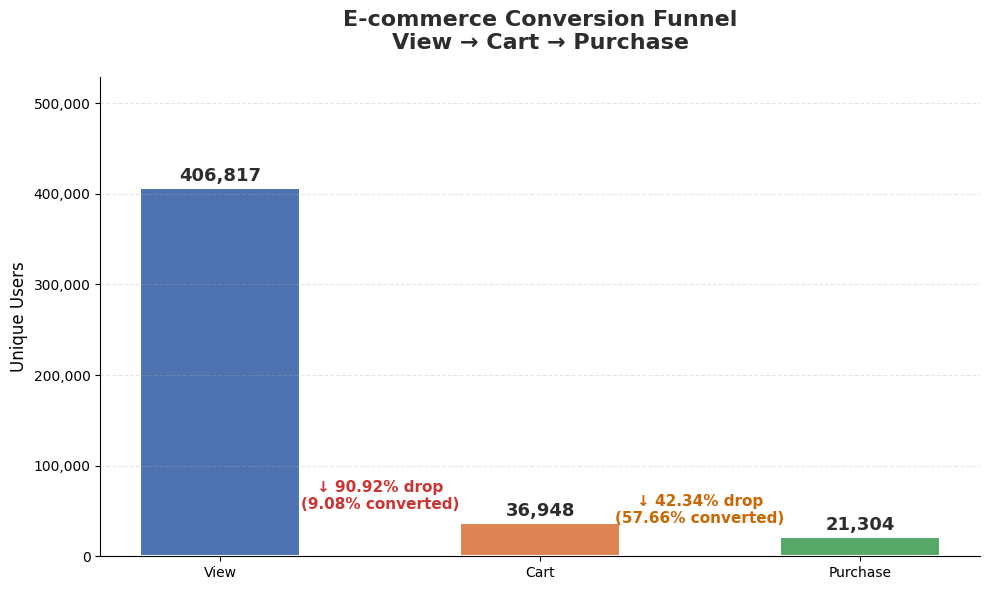

Saved.


In [4]:
# Funnel bar chart
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#4C72B0', '#DD8452', '#55A868']
bars   = ax.bar(stages, users, color=colors, width=0.5, edgecolor='white', linewidth=1.5)

# Add value labels on bars
for bar, user_count in zip(bars, users):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3000,
        f'{user_count:,}',
        ha='center', va='bottom',
        fontsize=13, fontweight='bold', color='#2d2d2d'
    )

# Add conversion rate annotations between bars
ax.annotate(
    f'↓ {drop_view_cart}% drop\n({view_to_cart}% converted)',
    xy=(0.5, users[1] + 15000),
    fontsize=11, ha='center', color='#cc3333',
    fontweight='bold'
)
ax.annotate(
    f'↓ {drop_cart_purchase}% drop\n({cart_to_purchase}% converted)',
    xy=(1.5, users[2] + 15000),
    fontsize=11, ha='center', color='#cc6600',
    fontweight='bold'
)

ax.set_title(
    'E-commerce Conversion Funnel\nView → Cart → Purchase',
    fontsize=16, fontweight='bold', pad=20, color='#2d2d2d'
)
ax.set_ylabel('Unique Users', fontsize=12)
ax.set_ylim(0, max(users) * 1.3)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{int(x):,}')
)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(
    'D:/Projects/e-commerce_funnel_analysis/images/02_funnel_chart.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Saved.")

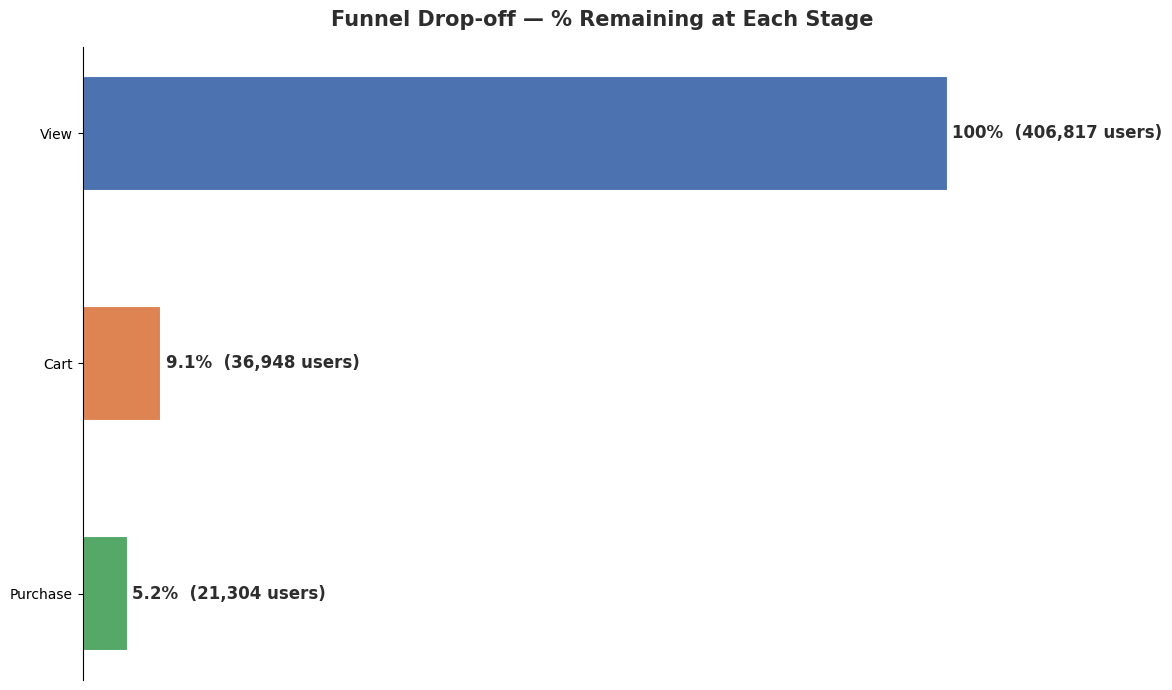

Saved.


In [5]:
# Funnel with percentage labels (waterfall style)
fig, ax = plt.subplots(figsize=(12, 7))

# Normalised to 100%
pct = [100, round(users[1]/users[0]*100, 1), round(users[2]/users[0]*100, 1)]
colors_wf = ['#4C72B0', '#DD8452', '#55A868']

bars = ax.barh(stages[::-1], pct[::-1], color=colors_wf[::-1],
               height=0.5, edgecolor='white', linewidth=1.5)

for bar, p, u in zip(bars, pct[::-1], users[::-1]):
    ax.text(p + 0.5, bar.get_y() + bar.get_height()/2,
            f'{p}%  ({u:,} users)',
            va='center', fontsize=12, fontweight='bold', color='#2d2d2d')

ax.set_xlim(0, 120)
ax.set_xlabel('% of Users who Viewed', fontsize=12)
ax.set_title(
    'Funnel Drop-off — % Remaining at Each Stage',
    fontsize=15, fontweight='bold', pad=15, color='#2d2d2d'
)
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.xaxis.set_visible(False)
ax.grid(False)

plt.tight_layout()
plt.savefig(
    'D:/Projects/e-commerce_funnel_analysis/images/02_funnel_waterfall.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Saved.")

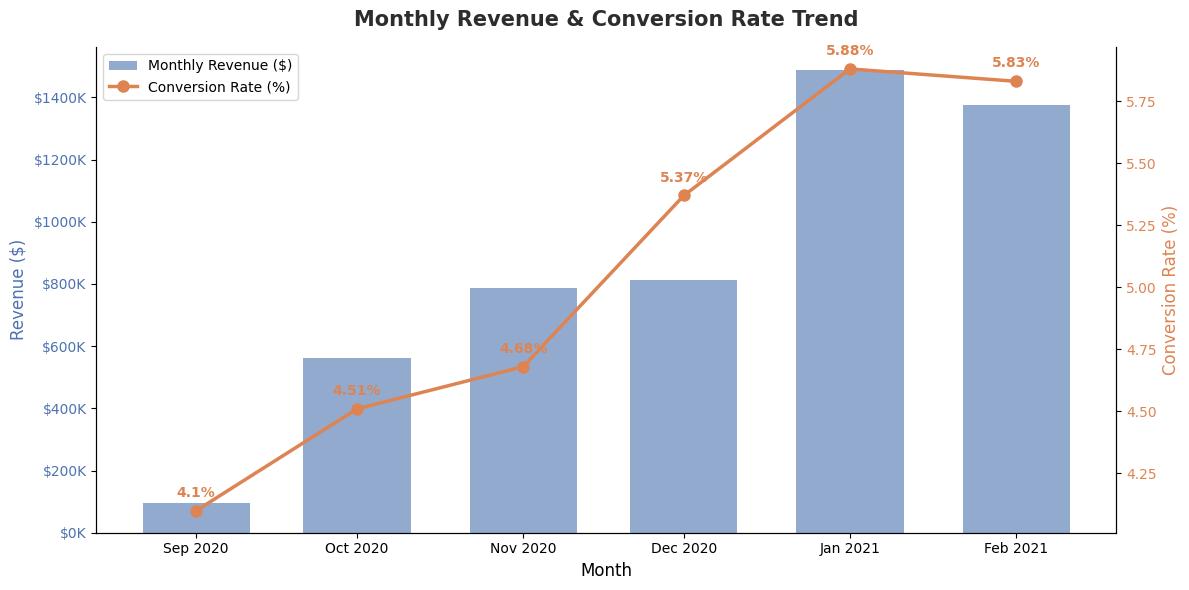

Saved.


In [6]:
# Monthly conversion trend
query_monthly = """
SELECT
    DATE_TRUNC('month', event_time) AS month,
    COUNT(DISTINCT CASE WHEN event_type = 'view'
          THEN user_id END)         AS users_viewed,
    COUNT(DISTINCT CASE WHEN event_type = 'purchase'
          THEN user_id END)         AS users_purchased,
    ROUND(SUM(price) FILTER
          (WHERE event_type = 'purchase'), 2) AS revenue
FROM events_clean
GROUP BY DATE_TRUNC('month', event_time)
ORDER BY month;
"""
monthly_df = pd.read_sql(query_monthly, engine)
monthly_df['month'] = pd.to_datetime(monthly_df['month'])
monthly_df['conversion_rate'] = (
    monthly_df['users_purchased'] / monthly_df['users_viewed'] * 100
).round(2)

fig, ax1 = plt.subplots(figsize=(12, 6))

# Revenue bars
ax1.bar(monthly_df['month'], monthly_df['revenue'],
        color='#4C72B0', alpha=0.6, width=20,
        label='Monthly Revenue ($)')
ax1.set_ylabel('Revenue ($)', fontsize=12, color='#4C72B0')
ax1.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K')
)
ax1.tick_params(axis='y', labelcolor='#4C72B0')

# Conversion rate line
ax2 = ax1.twinx()
ax2.plot(monthly_df['month'], monthly_df['conversion_rate'],
         color='#DD8452', marker='o', linewidth=2.5,
         markersize=8, label='Conversion Rate (%)')
ax2.set_ylabel('Conversion Rate (%)', fontsize=12, color='#DD8452')
ax2.tick_params(axis='y', labelcolor='#DD8452')

for x, y in zip(monthly_df['month'], monthly_df['conversion_rate']):
    ax2.annotate(f'{y}%', (x, y),
                 textcoords='offset points', xytext=(0, 10),
                 ha='center', fontsize=10, color='#DD8452',
                 fontweight='bold')

ax1.set_title(
    'Monthly Revenue & Conversion Rate Trend',
    fontsize=15, fontweight='bold', pad=15, color='#2d2d2d'
)
ax1.set_xlabel('Month', fontsize=12)
ax1.xaxis.set_major_formatter(
    plt.matplotlib.dates.DateFormatter('%b %Y')
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.spines[['top']].set_visible(False)
ax2.spines[['top']].set_visible(False)
plt.tight_layout()
plt.savefig(
    'D:/Projects/e-commerce_funnel_analysis/images/02_monthly_trend.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Saved.")